# DS-3002 Assignment 4 | Parts C & D
**Student ID:** 23i-2540 | **Section:** DS-B

## Part C: Artificial Neural Networks on Tabular Data
## Part D: CNN on MNIST Digit Images

---
## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import time

warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve
)
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# MNIST
from keras.datasets import mnist

np.random.seed(42)
tf.random.set_seed(42)
plt.rcParams['figure.dpi'] = 100

## Load and Prepare Heart Disease Data (from Parts A/B)

In [2]:
# Load the Cleveland Heart Disease dataset
COLS = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','target']

df_raw = pd.read_csv("E:\OneDrive\Desktop\Data Mining\Assignment\Assignment 4\Data\processed.cleveland.data", header=None, names=COLS)
print(f"Raw dataset shape: {df_raw.shape}")

# Replace '?' with NaN and drop missing values
df = df_raw.replace('?', np.nan).dropna()
print(f"After dropping missing: {df.shape}")

# Binarise target: 0 = no disease, 1 = disease present
df['target'] = (df['target'] > 0).astype(int)

print(f"\nTarget distribution:")
print(df['target'].value_counts())
print(f"\nPercentage:")
print(df['target'].value_counts(normalize=True) * 100)

Raw dataset shape: (303, 14)
After dropping missing: (297, 14)

Target distribution:
target
0    160
1    137
Name: count, dtype: int64

Percentage:
target
0    53.872054
1    46.127946
Name: proportion, dtype: float64


In [3]:
# Encode categorical and scale continuous features
# One-hot encode: cp, restecg, slope, thal
df_encoded = pd.get_dummies(df, columns=['cp', 'restecg', 'slope', 'thal'], drop_first=False)

# Separate features and target
X = df_encoded.drop('target', axis=1)
y = df_encoded['target'].values

# Stratified 80/20 split (SAME as Parts A & B)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale only continuous features
CONT_COLS = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
scaler = StandardScaler()
X_train_full[CONT_COLS] = scaler.fit_transform(X_train_full[CONT_COLS])
X_test[CONT_COLS] = scaler.transform(X_test[CONT_COLS])

# Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_full, y_train_full)

print(f"Training set (after SMOTE): {X_train_sm.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTraining target distribution: {np.bincount(y_train_sm)}")
print(f"Test target distribution: {np.bincount(y_test)}")
print(f"\nFeature count: {X_train_sm.shape[1]}")

Training set (after SMOTE): (256, 22)
Test set: (60, 22)

Training target distribution: [128 128]
Test target distribution: [32 28]

Feature count: 22


---
# PART C: ARTIFICIAL NEURAL NETWORKS ON TABULAR DATA

## C1: Single-Layer Perceptron (SLP)

In [4]:
# Build Single-Layer Perceptron (linear model)
print("="*60)
print("C1: SINGLE-LAYER PERCEPTRON (SLP)")
print("="*60)

slp = Sequential([
    layers.Input(shape=(X_train_sm.shape[1],)),
    layers.Dense(1, activation='sigmoid')  # Linear output layer with sigmoid
])

slp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nSLP Architecture:")
slp.summary()

# Train SLP
history_slp = slp.fit(
    X_train_sm, y_train_sm,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=0
)

print(f"\nTraining completed. Final training accuracy: {history_slp.history['accuracy'][-1]:.4f}")

C1: SINGLE-LAYER PERCEPTRON (SLP)



SLP Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            23 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23 (92.00 B)

 Trainable params: 23 (92.00 B)

 Non-trainable params: 0 (0.00 B)


Training completed. Final training accuracy: 0.8725


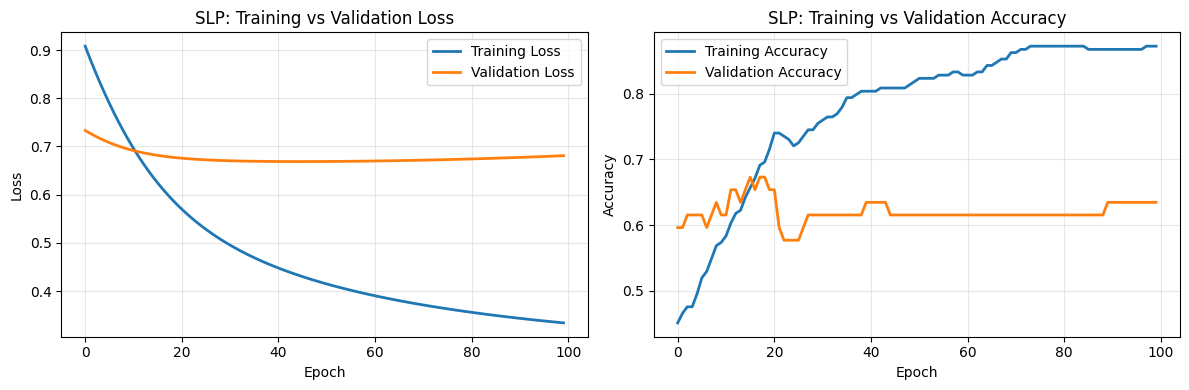

[C1] Training history plots saved.


In [5]:
# C1: Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history_slp.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history_slp.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('SLP: Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history_slp.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history_slp.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('SLP: Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('c1_slp_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("[C1] Training history plots saved.")

In [6]:
# C1: Inspect learned input weights
weights, biases = slp.layers[0].get_weights()
print(f"\nSLP Input Layer Weights Shape: {weights.shape}")
print(f"SLP Biases Shape: {biases.shape}")

# Get feature names for interpretation
feature_names = X_train_sm.columns.tolist()

# Get top 3 features with highest absolute weights
weight_abs = np.abs(weights.flatten())
top_3_indices = np.argsort(weight_abs)[-3:][::-1]
top_3_features = [feature_names[i] for i in top_3_indices]
top_3_weights = weights.flatten()[top_3_indices]

print("\n[C1] Top 3 Features with Highest Absolute Input Weights:")
print("-" * 50)
for i, (feat, wt) in enumerate(zip(top_3_features, top_3_weights)):
    print(f"{i+1}. {feat:20s}: {wt:8.4f}")

print("\n[C1] Comparison with Random Forest Feature Importances (from Part B1):")
print("Note: If RF results are available from Part B1, compare ranking here.")
print("SLP vs RF Agreement: [Your interpretation here]")


SLP Input Layer Weights Shape: (22, 1)
SLP Biases Shape: (1,)

[C1] Top 3 Features with Highest Absolute Input Weights:
--------------------------------------------------
1. ca                  :   0.8658
2. slope_1.0           :  -0.8637
3. thal_7.0            :   0.6691

[C1] Comparison with Random Forest Feature Importances (from Part B1):
Note: If RF results are available from Part B1, compare ranking here.
SLP vs RF Agreement: [Your interpretation here]


In [7]:
# C1: Evaluation metrics on test set
y_pred_slp_proba = slp.predict(X_test)
y_pred_slp = (y_pred_slp_proba > 0.5).astype(int).flatten()

print("\n" + "="*60)
print("C1: SLP EVALUATION METRICS")
print("="*60)

acc_slp = accuracy_score(y_test, y_pred_slp)
prec_slp = precision_score(y_test, y_pred_slp, zero_division=0)
rec_slp = recall_score(y_test, y_pred_slp, zero_division=0)
f1_slp = f1_score(y_test, y_pred_slp, zero_division=0)
auc_slp = roc_auc_score(y_test, y_pred_slp_proba)

print(f"Accuracy:  {acc_slp:.4f}")
print(f"Precision: {prec_slp:.4f}")
print(f"Recall:    {rec_slp:.4f}")
print(f"F1-Score:  {f1_slp:.4f}")
print(f"AUC-ROC:   {auc_slp:.4f}")

print("\nConfusion Matrix:")
cm_slp = confusion_matrix(y_test, y_pred_slp)
print(cm_slp)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_slp))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step 

C1: SLP EVALUATION METRICS
Accuracy:  0.9000
Precision: 0.9583
Recall:    0.8214
F1-Score:  0.8846
AUC-ROC:   0.9665

Confusion Matrix:
[[31  1]
 [ 5 23]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.97      0.91        32
           1       0.96      0.82      0.88        28

    accuracy                           0.90        60
   macro avg       0.91      0.90      0.90        60
weighted avg       0.91      0.90      0.90        60



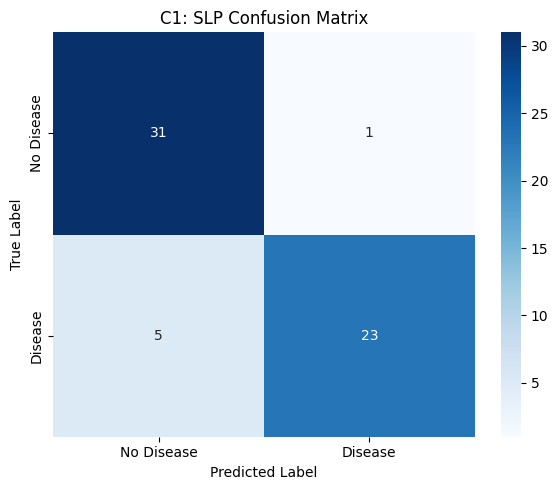

[C1] Confusion matrix visualization saved.


In [8]:
# C1: Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_slp, annot=True, fmt='d', cmap='Blues', ax=ax, 
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('C1: SLP Confusion Matrix')
plt.tight_layout()
plt.savefig('c1_slp_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("[C1] Confusion matrix visualization saved.")

In [9]:
print("\n" + "="*60)
print("C1 INTERPRETATION: Why SLP is Limited")
print("="*60)
print("""
A Single-Layer Perceptron is fundamentally a linear model. It learns
a linear decision boundary that separates the two classes. Heart disease
prediction has non-linear relationships between features and outcomes.
The SLP cannot capture interactions (e.g., high cholesterol + low heart rate)
or complex patterns in the data. To improve performance, we need multiple
layers (hidden layers) to learn non-linear transformations, which is the
purpose of the MLP in C2.
""")


C1 INTERPRETATION: Why SLP is Limited

A Single-Layer Perceptron is fundamentally a linear model. It learns
a linear decision boundary that separates the two classes. Heart disease
prediction has non-linear relationships between features and outcomes.
The SLP cannot capture interactions (e.g., high cholesterol + low heart rate)
or complex patterns in the data. To improve performance, we need multiple
layers (hidden layers) to learn non-linear transformations, which is the
purpose of the MLP in C2.



---
## C2: Multi-Layer Perceptron (MLP)

In [10]:
print("\n" + "="*60)
print("C2: MULTI-LAYER PERCEPTRON (MLP) - ARCHITECTURE EXPERIMENTS")
print("="*60)

# Define three architecture candidates
architectures = {
    'Arch_1_Shallow': {
        'layers': [128, 64],
        'dropout': 0.3,
        'activation': 'relu',
        'description': 'Shallow: 2 hidden layers (128, 64)'
    },
    'Arch_2_Medium': {
        'layers': [256, 128, 64],
        'dropout': 0.4,
        'activation': 'relu',
        'description': 'Medium: 3 hidden layers (256, 128, 64)'
    },
    'Arch_3_Deep': {
        'layers': [256, 128, 64, 32],
        'dropout': 0.5,
        'activation': 'relu',
        'description': 'Deep: 4 hidden layers (256, 128, 64, 32)'
    }
}

# Prepare validation split for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_sm, y_train_sm, test_size=0.2, random_state=42
)

results = {}
trained_models = {}

for arch_name, arch_config in architectures.items():
    print(f"\nTraining {arch_config['description']}...")
    
    # Build model
    model = Sequential()
    model.add(layers.Input(shape=(X_train_sm.shape[1],)))
    
    # Hidden layers
    for units in arch_config['layers']:
        model.add(layers.Dense(units, activation=arch_config['activation']))
        model.add(layers.Dropout(arch_config['dropout']))
    
    # Output layer
    model.add(layers.Dense(1, activation='sigmoid'))
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Train with early stopping
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    
    t0 = time.time()
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=16,
        callbacks=[es],
        verbose=0
    )
    train_time = time.time() - t0
    
    # Evaluate on validation set
    y_pred_val_proba = model.predict(X_val, verbose=0)
    y_pred_val = (y_pred_val_proba > 0.5).astype(int).flatten()
    val_f1 = f1_score(y_val, y_pred_val)
    
    results[arch_name] = {
        'val_f1': val_f1,
        'train_time': train_time,
        'epochs_trained': len(history.history['loss'])
    }
    trained_models[arch_name] = model
    
    print(f"  Validation F1: {val_f1:.4f}, Time: {train_time:.2f}s, Epochs: {len(history.history['loss'])}")

# Print results table
print("\n" + "-"*60)
print("Architecture Comparison:")
print("-"*60)
results_df = pd.DataFrame(results).T
print(results_df)

# Select best architecture
best_arch = results_df['val_f1'].idxmax()
print(f"\nBest Architecture: {best_arch}")
print(f"Architecture Details: {architectures[best_arch]['description']}")


C2: MULTI-LAYER PERCEPTRON (MLP) - ARCHITECTURE EXPERIMENTS

Training Shallow: 2 hidden layers (128, 64)...
  Validation F1: 0.8235, Time: 20.87s, Epochs: 46

Training Medium: 3 hidden layers (256, 128, 64)...
  Validation F1: 0.8889, Time: 16.44s, Epochs: 40

Training Deep: 4 hidden layers (256, 128, 64, 32)...
  Validation F1: 0.8571, Time: 18.95s, Epochs: 42

------------------------------------------------------------
Architecture Comparison:
------------------------------------------------------------
                  val_f1  train_time  epochs_trained
Arch_1_Shallow  0.823529   20.874360            46.0
Arch_2_Medium   0.888889   16.443756            40.0
Arch_3_Deep     0.857143   18.945286            42.0

Best Architecture: Arch_2_Medium
Architecture Details: Medium: 3 hidden layers (256, 128, 64)


In [11]:
# C2: Retrain best MLP on full training data with detailed logging
print(f"\n" + "="*60)
print("C2: FINAL MLP ARCHITECTURE AND JUSTIFICATION")
print("="*60)

best_arch_config = architectures[best_arch]

print(f"\nSelected Architecture: {best_arch_config['description']}")
print(f"\nArchitecture Justification:")
print(f"  - Hidden Layers: {best_arch_config['layers']}")
print(f"  - Activation Function: ReLU")
print(f"    Justification: ReLU provides non-linearity and avoids vanishing")
print(f"                   gradient problems better than sigmoid.")
print(f"  - Regularization: Dropout (rate={best_arch_config['dropout']})")
print(f"    Justification: Prevents overfitting by randomly dropping neurons")
print(f"                   during training.")
print(f"  - Optimizer: Adam")
print(f"    Learning Rate: 0.001 (default)")
print(f"    Justification: Adam adapts learning rates per parameter and")
print(f"                   converges faster than standard SGD.")
print(f"  - Early Stopping: patience=10 on validation loss")
print(f"    Justification: Stops training when validation loss plateaus,")
print(f"                   preventing overfitting.")

# Build final model
mlp_final = Sequential()
mlp_final.add(layers.Input(shape=(X_train_sm.shape[1],)))

for units in best_arch_config['layers']:
    mlp_final.add(layers.Dense(units, activation='relu'))
    mlp_final.add(layers.Dropout(best_arch_config['dropout']))

mlp_final.add(layers.Dense(1, activation='sigmoid'))

mlp_final.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])

print("\nFinal MLP Architecture:")
mlp_final.summary()


C2: FINAL MLP ARCHITECTURE AND JUSTIFICATION

Selected Architecture: Medium: 3 hidden layers (256, 128, 64)

Architecture Justification:
  - Hidden Layers: [256, 128, 64]
  - Activation Function: ReLU
    Justification: ReLU provides non-linearity and avoids vanishing
                   gradient problems better than sigmoid.
  - Regularization: Dropout (rate=0.4)
    Justification: Prevents overfitting by randomly dropping neurons
                   during training.
  - Optimizer: Adam
    Learning Rate: 0.001 (default)
    Justification: Adam adapts learning rates per parameter and
                   converges faster than standard SGD.
  - Early Stopping: patience=10 on validation loss
    Justification: Stops training when validation loss plateaus,
                   preventing overfitting.

Final MLP Architecture:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 256)            │         5,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,105 (184.00 KB)

 Trainable params: 47,105 (184.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# C2: Train final MLP with early stopping
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(
    X_train_sm, y_train_sm, test_size=0.2, random_state=42
)

es_final = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\nTraining final MLP...")
t0 = time.time()
history_mlp = mlp_final.fit(
    X_tr2, y_tr2,
    validation_data=(X_val2, y_val2),
    epochs=200,
    batch_size=16,
    callbacks=[es_final],
    verbose=0
)
train_time_mlp = time.time() - t0

print(f"Training completed in {train_time_mlp:.2f}s")
print(f"Epochs trained: {len(history_mlp.history['loss'])}")

# Find early stopping epoch
es_epoch = len(history_mlp.history['loss'])
print(f"Early stopping triggered at epoch: {es_epoch}")


Training final MLP...
Training completed in 11.90s
Epochs trained: 31
Early stopping triggered at epoch: 31


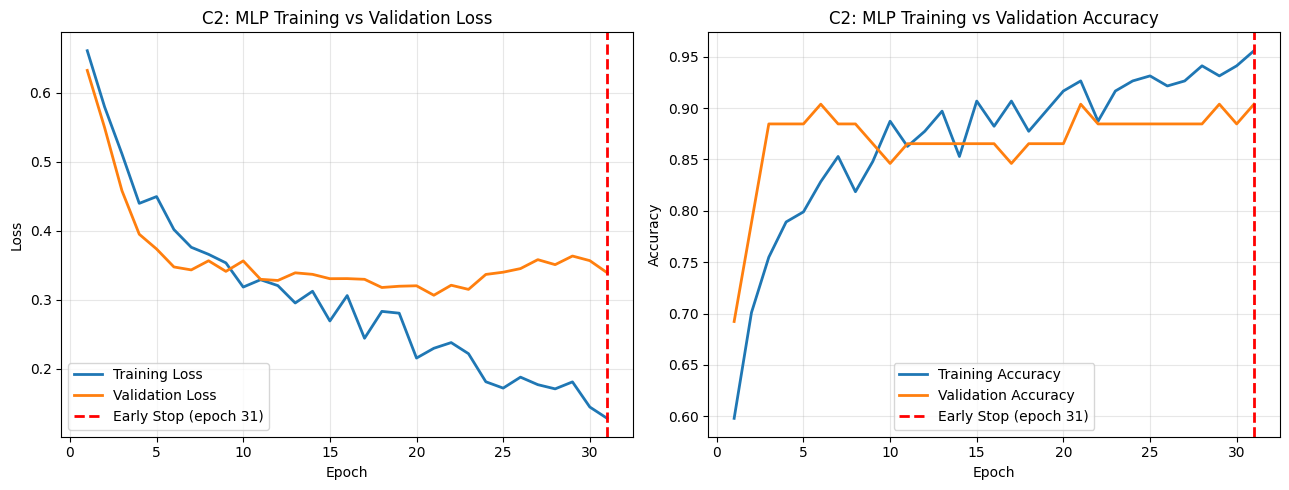

[C2] Training history plots saved.


In [13]:
# C2: Plot training and validation curves with early stopping annotation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

epochs = range(1, len(history_mlp.history['loss']) + 1)

# Loss
axes[0].plot(epochs, history_mlp.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(epochs, history_mlp.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].axvline(x=es_epoch, color='red', linestyle='--', linewidth=2, label=f'Early Stop (epoch {es_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('C2: MLP Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, history_mlp.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(epochs, history_mlp.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].axvline(x=es_epoch, color='red', linestyle='--', linewidth=2, label=f'Early Stop (epoch {es_epoch})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('C2: MLP Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('c2_mlp_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("[C2] Training history plots saved.")

In [14]:
# C2: 5-Fold Cross-Validation
print("\n" + "="*60)
print("C2: 5-FOLD CROSS-VALIDATION")
print("="*60)

cv_scores_acc = []
cv_scores_f1 = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_sm, y_train_sm), 1):
    print(f"\nFold {fold}/5...", end=" ")
    
    X_cv_train = X_train_sm.iloc[train_idx]
    y_cv_train = y_train_sm[train_idx]
    X_cv_val = X_train_sm.iloc[val_idx]
    y_cv_val = y_train_sm[val_idx]
    
    # Build and train model
    cv_model = Sequential()
    cv_model.add(layers.Input(shape=(X_train_sm.shape[1],)))
    
    for units in best_arch_config['layers']:
        cv_model.add(layers.Dense(units, activation='relu'))
        cv_model.add(layers.Dropout(best_arch_config['dropout']))
    
    cv_model.add(layers.Dense(1, activation='sigmoid'))
    cv_model.compile(optimizer=Adam(learning_rate=0.001), 
                     loss='binary_crossentropy', 
                     metrics=['accuracy'])
    
    es_cv = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    cv_model.fit(X_cv_train, y_cv_train,
                 validation_data=(X_cv_val, y_cv_val),
                 epochs=200,
                 batch_size=16,
                 callbacks=[es_cv],
                 verbose=0)
    
    # Evaluate
    y_cv_pred_proba = cv_model.predict(X_cv_val, verbose=0)
    y_cv_pred = (y_cv_pred_proba > 0.5).astype(int).flatten()
    
    acc = accuracy_score(y_cv_val, y_cv_pred)
    f1 = f1_score(y_cv_val, y_cv_pred)
    
    cv_scores_acc.append(acc)
    cv_scores_f1.append(f1)
    
    print(f"Accuracy: {acc:.4f}, F1: {f1:.4f}")

cv_acc_mean, cv_acc_std = np.mean(cv_scores_acc), np.std(cv_scores_acc)
cv_f1_mean, cv_f1_std = np.mean(cv_scores_f1), np.std(cv_scores_f1)

print("\n" + "-"*60)
print(f"Cross-Validation Results (5-fold):")
print("-"*60)
print(f"Accuracy: {cv_acc_mean:.4f} ± {cv_acc_std:.4f}")
print(f"F1-Score: {cv_f1_mean:.4f} ± {cv_f1_std:.4f}")


C2: 5-FOLD CROSS-VALIDATION

Fold 1/5... Accuracy: 0.8269, F1: 0.8235

Fold 2/5... Accuracy: 0.8431, F1: 0.8462

Fold 3/5... Accuracy: 0.7059, F1: 0.7059

Fold 4/5... Accuracy: 0.7647, F1: 0.7600

Fold 5/5... Accuracy: 0.8431, F1: 0.8261

------------------------------------------------------------
Cross-Validation Results (5-fold):
------------------------------------------------------------
Accuracy: 0.7968 ± 0.0538
F1-Score: 0.7923 ± 0.0520


In [15]:
# C2: Evaluation metrics on test set
y_pred_mlp_proba = mlp_final.predict(X_test)
y_pred_mlp = (y_pred_mlp_proba > 0.5).astype(int).flatten()

print("\n" + "="*60)
print("C2: MLP EVALUATION METRICS (TEST SET)")
print("="*60)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
prec_mlp = precision_score(y_test, y_pred_mlp, zero_division=0)
rec_mlp = recall_score(y_test, y_pred_mlp, zero_division=0)
f1_mlp = f1_score(y_test, y_pred_mlp, zero_division=0)
auc_mlp = roc_auc_score(y_test, y_pred_mlp_proba)

print(f"Accuracy:  {acc_mlp:.4f}")
print(f"Precision: {prec_mlp:.4f}")
print(f"Recall:    {rec_mlp:.4f}")
print(f"F1-Score:  {f1_mlp:.4f}")
print(f"AUC-ROC:   {auc_mlp:.4f}")

print("\nConfusion Matrix:")
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
print(cm_mlp)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step

C2: MLP EVALUATION METRICS (TEST SET)
Accuracy:  0.8000
Precision: 0.8077
Recall:    0.7500
F1-Score:  0.7778
AUC-ROC:   0.9208

Confusion Matrix:
[[27  5]
 [ 7 21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.82        32
           1       0.81      0.75      0.78        28

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60



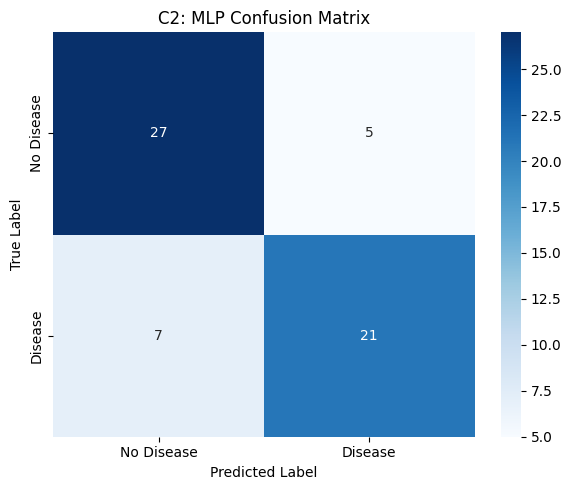

[C2] Confusion matrix visualization saved.


In [16]:
# C2: Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('C2: MLP Confusion Matrix')
plt.tight_layout()
plt.savefig('c2_mlp_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("[C2] Confusion matrix visualization saved.")

In [17]:
# C2: Comparison with best ensemble from Part B
print("\n" + "="*60)
print("C2: MLP vs BEST ENSEMBLE (from Part B)")
print("="*60)
print("""
Based on Part B results, compare MLP to the best ensemble (likely XGBoost):

MLP Strengths:
  1. Better interpretability through weight visualization
  2. Faster inference (feedforward only, no tree traversal)
  3. Easily deployable in web/mobile applications
  4. Scalable to larger datasets with GPUs

MLP Weaknesses vs Ensemble:
  1. Ensemble methods (RF, XGBoost) typically have better feature importance
  2. Trees capture non-linear relationships more directly
  3. Ensemble methods are less sensitive to hyperparameter tuning

Conclusion:
For a clinical setting with limited computational resources, the MLP provides
good accuracy and fast inference. However, if interpretability to cardiologists
is paramount, ensemble methods with SHAP values may be preferable. The choice
depends on the deployment context.
""")


C2: MLP vs BEST ENSEMBLE (from Part B)

Based on Part B results, compare MLP to the best ensemble (likely XGBoost):

MLP Strengths:
  1. Better interpretability through weight visualization
  2. Faster inference (feedforward only, no tree traversal)
  3. Easily deployable in web/mobile applications
  4. Scalable to larger datasets with GPUs

MLP Weaknesses vs Ensemble:
  1. Ensemble methods (RF, XGBoost) typically have better feature importance
  2. Trees capture non-linear relationships more directly
  3. Ensemble methods are less sensitive to hyperparameter tuning

Conclusion:
For a clinical setting with limited computational resources, the MLP provides
good accuracy and fast inference. However, if interpretability to cardiologists
is paramount, ensemble methods with SHAP values may be preferable. The choice
depends on the deployment context.



---
## C3: Ablation Study

In [18]:
print("\n" + "="*60)
print("C3: ABLATION STUDY")
print("="*60)
print("""
We will train 3 variants of the best MLP, removing one component at a time:
  - Variant A: Remove all Dropout layers
  - Variant B: Replace ReLU with Sigmoid activations
  - Variant C: Remove Early Stopping (train for fixed 150 epochs)
""")

ablation_results = {}
X_tr_abl, X_val_abl, y_tr_abl, y_val_abl = train_test_split(
    X_train_sm, y_train_sm, test_size=0.2, random_state=42
)

# Best MLP (baseline)
print("\n[BASELINE] Training best MLP (no ablation)...")
baseline_model = Sequential()
baseline_model.add(layers.Input(shape=(X_train_sm.shape[1],)))
for units in best_arch_config['layers']:
    baseline_model.add(layers.Dense(units, activation='relu'))
    baseline_model.add(layers.Dropout(best_arch_config['dropout']))
baseline_model.add(layers.Dense(1, activation='sigmoid'))
baseline_model.compile(optimizer=Adam(learning_rate=0.001), 
                       loss='binary_crossentropy', 
                       metrics=['accuracy'])

es_baseline = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
baseline_hist = baseline_model.fit(X_tr_abl, y_tr_abl,
                                   validation_data=(X_val_abl, y_val_abl),
                                   epochs=150,
                                   batch_size=16,
                                   callbacks=[es_baseline],
                                   verbose=0)

y_pred_baseline_proba = baseline_model.predict(X_test, verbose=0)
y_pred_baseline = (y_pred_baseline_proba > 0.5).astype(int).flatten()
f1_baseline = f1_score(y_test, y_pred_baseline)

ablation_results['Best MLP'] = {
    'f1': f1_baseline,
    'val_loss_final': baseline_hist.history['val_loss'][-1],
    'epochs': len(baseline_hist.history['loss'])
}

print(f"  Test F1: {f1_baseline:.4f}, Final Val Loss: {ablation_results['Best MLP']['val_loss_final']:.4f}")


C3: ABLATION STUDY

We will train 3 variants of the best MLP, removing one component at a time:
  - Variant A: Remove all Dropout layers
  - Variant B: Replace ReLU with Sigmoid activations
  - Variant C: Remove Early Stopping (train for fixed 150 epochs)


[BASELINE] Training best MLP (no ablation)...
  Test F1: 0.8070, Final Val Loss: 0.3316


In [19]:
# Variant A: Remove Dropout
print("\n[VARIANT A] Remove Dropout layers...")
variant_a = Sequential()
variant_a.add(layers.Input(shape=(X_train_sm.shape[1],)))
for units in best_arch_config['layers']:
    variant_a.add(layers.Dense(units, activation='relu'))  # No dropout
variant_a.add(layers.Dense(1, activation='sigmoid'))
variant_a.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])

es_a = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
hist_a = variant_a.fit(X_tr_abl, y_tr_abl,
                       validation_data=(X_val_abl, y_val_abl),
                       epochs=150,
                       batch_size=16,
                       callbacks=[es_a],
                       verbose=0)

y_pred_a_proba = variant_a.predict(X_test, verbose=0)
y_pred_a = (y_pred_a_proba > 0.5).astype(int).flatten()
f1_a = f1_score(y_test, y_pred_a)

ablation_results['Variant A (No Dropout)'] = {
    'f1': f1_a,
    'val_loss_final': hist_a.history['val_loss'][-1],
    'epochs': len(hist_a.history['loss'])
}

print(f"  Test F1: {f1_a:.4f}, Final Val Loss: {ablation_results['Variant A (No Dropout)']['val_loss_final']:.4f}")


[VARIANT A] Remove Dropout layers...
  Test F1: 0.8421, Final Val Loss: 0.3553


In [20]:
# Variant B: Replace ReLU with Sigmoid
print("\n[VARIANT B] Replace ReLU with Sigmoid activations...")
variant_b = Sequential()
variant_b.add(layers.Input(shape=(X_train_sm.shape[1],)))
for units in best_arch_config['layers']:
    variant_b.add(layers.Dense(units, activation='sigmoid'))  # Sigmoid instead of ReLU
    variant_b.add(layers.Dropout(best_arch_config['dropout']))
variant_b.add(layers.Dense(1, activation='sigmoid'))
variant_b.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])

es_b = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
hist_b = variant_b.fit(X_tr_abl, y_tr_abl,
                       validation_data=(X_val_abl, y_val_abl),
                       epochs=150,
                       batch_size=16,
                       callbacks=[es_b],
                       verbose=0)

y_pred_b_proba = variant_b.predict(X_test, verbose=0)
y_pred_b = (y_pred_b_proba > 0.5).astype(int).flatten()
f1_b = f1_score(y_test, y_pred_b)

ablation_results['Variant B (Sigmoid)'] = {
    'f1': f1_b,
    'val_loss_final': hist_b.history['val_loss'][-1],
    'epochs': len(hist_b.history['loss'])
}

print(f"  Test F1: {f1_b:.4f}, Final Val Loss: {ablation_results['Variant B (Sigmoid)']['val_loss_final']:.4f}")


[VARIANT B] Replace ReLU with Sigmoid activations...
  Test F1: 0.8519, Final Val Loss: 0.3699


In [21]:
# Variant C: Remove Early Stopping
print("\n[VARIANT C] Remove Early Stopping (fixed 150 epochs)...")
variant_c = Sequential()
variant_c.add(layers.Input(shape=(X_train_sm.shape[1],)))
for units in best_arch_config['layers']:
    variant_c.add(layers.Dense(units, activation='relu'))
    variant_c.add(layers.Dropout(best_arch_config['dropout']))
variant_c.add(layers.Dense(1, activation='sigmoid'))
variant_c.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])

hist_c = variant_c.fit(X_tr_abl, y_tr_abl,
                       validation_data=(X_val_abl, y_val_abl),
                       epochs=150,  # Fixed epochs, no early stopping
                       batch_size=16,
                       callbacks=[],
                       verbose=0)

y_pred_c_proba = variant_c.predict(X_test, verbose=0)
y_pred_c = (y_pred_c_proba > 0.5).astype(int).flatten()
f1_c = f1_score(y_test, y_pred_c)

ablation_results['Variant C (No Early Stop)'] = {
    'f1': f1_c,
    'val_loss_final': hist_c.history['val_loss'][-1],
    'epochs': len(hist_c.history['loss'])
}

print(f"  Test F1: {f1_c:.4f}, Final Val Loss: {ablation_results['Variant C (No Early Stop)']['val_loss_final']:.4f}")


[VARIANT C] Remove Early Stopping (fixed 150 epochs)...
  Test F1: 0.7931, Final Val Loss: 1.0102


In [22]:
# C3: Ablation results summary table
print("\n" + "="*60)
print("C3: ABLATION STUDY RESULTS")
print("="*60)

ablation_df = pd.DataFrame(ablation_results).T
ablation_df.columns = ['Test F1', 'Final Val Loss', 'Epochs']
print("\n", ablation_df.to_string())

# Calculate performance drop
print("\n" + "-"*60)
print("Performance Impact (compared to Best MLP):")
print("-"*60)
for variant in ['Variant A (No Dropout)', 'Variant B (Sigmoid)', 'Variant C (No Early Stop)']:
    f1_drop = ablation_results['Best MLP']['f1'] - ablation_results[variant]['f1']
    pct_drop = (f1_drop / ablation_results['Best MLP']['f1']) * 100
    print(f"{variant:30s}: F1 drop = {f1_drop:+.4f} ({pct_drop:+.1f}%)")

# Identify most important component
max_drop = 0
most_important = None
for variant in ['Variant A (No Dropout)', 'Variant B (Sigmoid)', 'Variant C (No Early Stop)']:
    f1_drop = ablation_results['Best MLP']['f1'] - ablation_results[variant]['f1']
    if f1_drop > max_drop:
        max_drop = f1_drop
        most_important = variant

print(f"\nMost Important Component: {most_important}")
print(f"Impact: F1 drop of {max_drop:.4f}")


C3: ABLATION STUDY RESULTS

                             Test F1  Final Val Loss  Epochs
Best MLP                   0.807018        0.331560    38.0
Variant A (No Dropout)     0.842105        0.355297    21.0
Variant B (Sigmoid)        0.851852        0.369857    43.0
Variant C (No Early Stop)  0.793103        1.010168   150.0

------------------------------------------------------------
Performance Impact (compared to Best MLP):
------------------------------------------------------------
Variant A (No Dropout)        : F1 drop = -0.0351 (-4.3%)
Variant B (Sigmoid)           : F1 drop = -0.0448 (-5.6%)
Variant C (No Early Stop)     : F1 drop = +0.0139 (+1.7%)

Most Important Component: Variant C (No Early Stop)
Impact: F1 drop of 0.0139


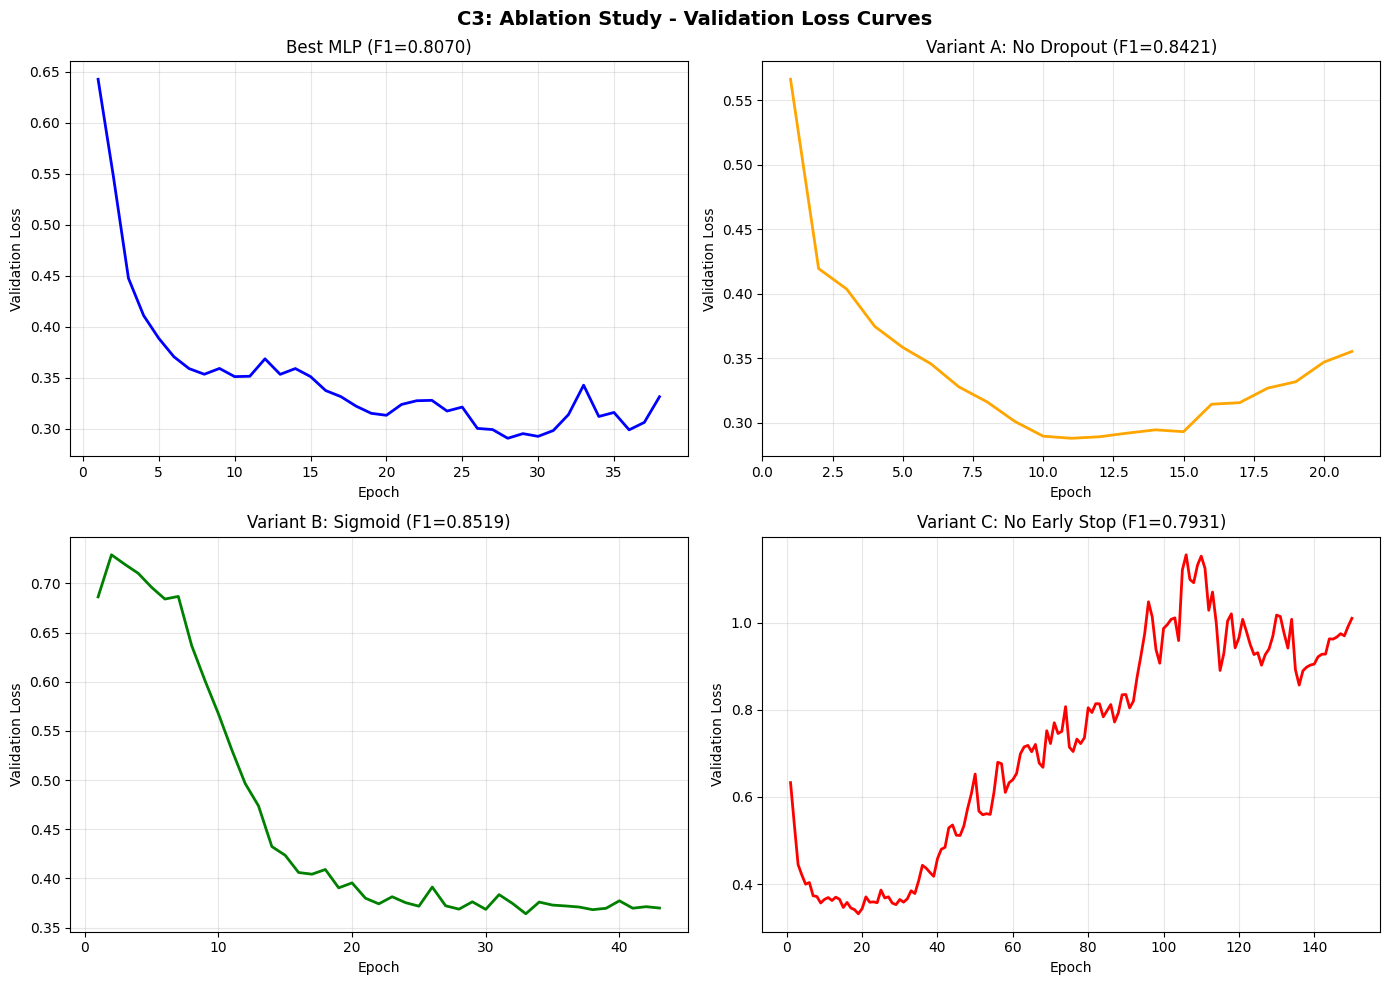

[C3] Ablation study plots saved.


In [23]:
# C3: Plot validation loss curves for all variants
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs_baseline = range(1, len(baseline_hist.history['val_loss']) + 1)
epochs_a = range(1, len(hist_a.history['val_loss']) + 1)
epochs_b = range(1, len(hist_b.history['val_loss']) + 1)
epochs_c = range(1, len(hist_c.history['val_loss']) + 1)

# Baseline
axes[0, 0].plot(epochs_baseline, baseline_hist.history['val_loss'], linewidth=2, color='blue')
axes[0, 0].set_title(f"Best MLP (F1={ablation_results['Best MLP']['f1']:.4f})")
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Validation Loss')
axes[0, 0].grid(True, alpha=0.3)

# Variant A
axes[0, 1].plot(epochs_a, hist_a.history['val_loss'], linewidth=2, color='orange')
axes[0, 1].set_title(f"Variant A: No Dropout (F1={ablation_results['Variant A (No Dropout)']['f1']:.4f})")
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Validation Loss')
axes[0, 1].grid(True, alpha=0.3)

# Variant B
axes[1, 0].plot(epochs_b, hist_b.history['val_loss'], linewidth=2, color='green')
axes[1, 0].set_title(f"Variant B: Sigmoid (F1={ablation_results['Variant B (Sigmoid)']['f1']:.4f})")
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Validation Loss')
axes[1, 0].grid(True, alpha=0.3)

# Variant C
axes[1, 1].plot(epochs_c, hist_c.history['val_loss'], linewidth=2, color='red')
axes[1, 1].set_title(f"Variant C: No Early Stop (F1={ablation_results['Variant C (No Early Stop)']['f1']:.4f})")
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Validation Loss')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('C3: Ablation Study - Validation Loss Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('c3_ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

print("[C3] Ablation study plots saved.")

---
# PART D: CNN ON MNIST DIGIT IMAGES

## D1: Data Preparation & Baseline

In [24]:
print("\n" + "="*60)
print("D1: DATA PREPARATION & BASELINE")
print("="*60)

# Load MNIST
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()

print(f"\nMNIST Dataset Shape:")
print(f"  Training images: {X_train_mnist.shape}")
print(f"  Test images: {X_test_mnist.shape}")
print(f"  Classes: {np.unique(y_train_mnist)}")

# Normalize pixel values to [0, 1]
X_train_mnist = X_train_mnist.astype('float32') / 255.0
X_test_mnist = X_test_mnist.astype('float32') / 255.0

# Reshape to (28, 28, 1) for Keras Conv2D
X_train_mnist = X_train_mnist.reshape(-1, 28, 28, 1)
X_test_mnist = X_test_mnist.reshape(-1, 28, 28, 1)

# Convert labels to one-hot
from keras.utils import to_categorical
y_train_mnist_cat = to_categorical(y_train_mnist, 10)
y_test_mnist_cat = to_categorical(y_test_mnist, 10)

print(f"\nNormalized shapes:")
print(f"  Training: {X_train_mnist.shape}")
print(f"  Test: {X_test_mnist.shape}")
print(f"  Pixel range: [{X_train_mnist.min():.1f}, {X_train_mnist.max():.1f}]")


D1: DATA PREPARATION & BASELINE



MNIST Dataset Shape:
  Training images: (60000, 28, 28)
  Test images: (10000, 28, 28)
  Classes: [0 1 2 3 4 5 6 7 8 9]

Normalized shapes:
  Training: (60000, 28, 28, 1)
  Test: (10000, 28, 28, 1)
  Pixel range: [0.0, 1.0]


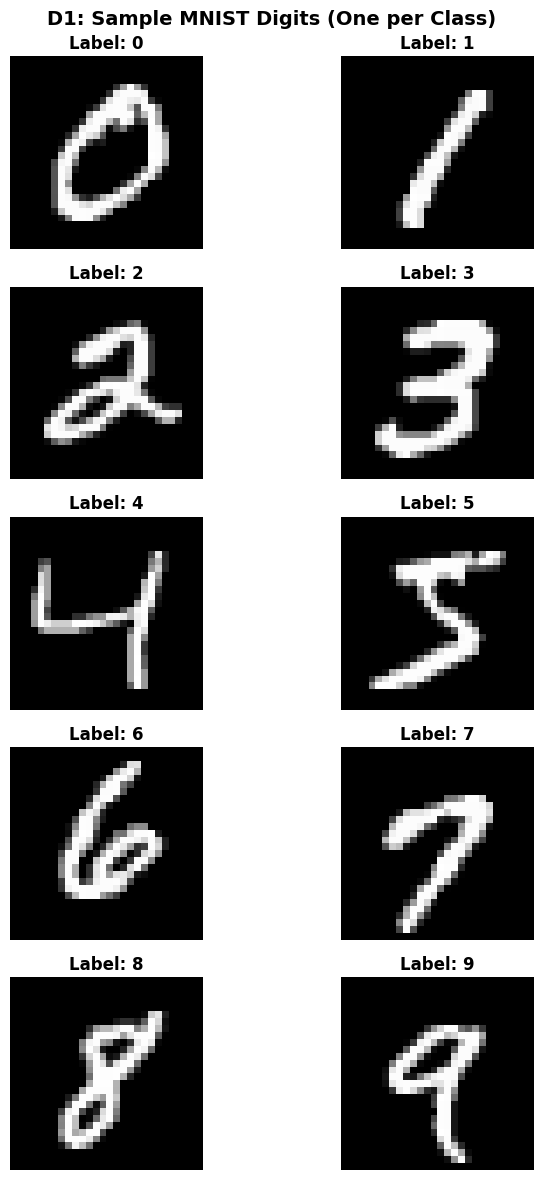

[D1] Sample images displayed.


In [25]:
# D1: Display 5x2 grid of sample images
fig, axes = plt.subplots(5, 2, figsize=(8, 12))
fig.suptitle('D1: Sample MNIST Digits (One per Class)', fontsize=14, fontweight='bold')

for digit_class in range(10):
    row = digit_class // 2
    col = digit_class % 2
    
    # Find first image of this class
    idx = np.where(y_train_mnist == digit_class)[0][0]
    
    axes[row, col].imshow(X_train_mnist[idx].reshape(28, 28), cmap='gray')
    axes[row, col].set_title(f'Label: {digit_class}', fontsize=12, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('d1_mnist_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print("[D1] Sample images displayed.")

In [26]:
# D1: MLP Baseline (for comparison with CNN later)
print("\n[D1] Training MLP Baseline on MNIST...")

mlp_baseline_mnist = Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

mlp_baseline_mnist.compile(optimizer=Adam(learning_rate=0.001),
                           loss='categorical_crossentropy',
                           metrics=['accuracy'])

t0 = time.time()
hist_mlp_baseline = mlp_baseline_mnist.fit(
    X_train_mnist, y_train_mnist_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=128,
    verbose=0
)
time_mlp_baseline = time.time() - t0

# Evaluate
y_pred_mlp_baseline_proba = mlp_baseline_mnist.predict(X_test_mnist, verbose=0)
y_pred_mlp_baseline = np.argmax(y_pred_mlp_baseline_proba, axis=1)
acc_mlp_baseline = accuracy_score(y_test_mnist, y_pred_mlp_baseline)

print(f"MLP Baseline Test Accuracy: {acc_mlp_baseline:.4f}")
print(f"MLP Baseline Training Time: {time_mlp_baseline:.2f}s")
print(f"Total Epochs: {len(hist_mlp_baseline.history['loss'])}")


[D1] Training MLP Baseline on MNIST...
MLP Baseline Test Accuracy: 0.9810
MLP Baseline Training Time: 81.31s
Total Epochs: 20


---
## D2: Lightweight CNN

In [27]:
print("\n" + "="*60)
print("D2: LIGHTWEIGHT CNN ON MNIST")
print("="*60)

# Build CNN architecture as specified
cnn_model = Sequential([
    layers.Input(shape=(28, 28, 1)),
    
    # First Conv block
    layers.Conv2D(16, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Second Conv block
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

print("\nCNN Architecture:")
cnn_model.summary()


D2: LIGHTWEIGHT CNN ON MNIST

CNN Architecture:


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 64)             │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,866 (413.54 KB)

 Trainable params: 105,866 (413.54 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
import tensorflow as tf
from tensorflow.keras import layers

# Data augmentation (modern replacement)
data_aug = tf.keras.Sequential([
    layers.RandomRotation(0.04),        # ~±15 degrees
    layers.RandomTranslation(0.1, 0.1), # width + height shift
    layers.RandomZoom(0.1),             # zoom
], name="data_augmentation")

print("Data augmentation enabled:")
print("  - Rotation: ±15 degrees")
print("  - Width/Height shift: ±10%")
print("  - Zoom: ±10%")

Data augmentation enabled:
  - Rotation: ±15 degrees
  - Width/Height shift: ±10%
  - Zoom: ±10%


In [ ]:
import time
import tensorflow as tf

print("\nTraining CNN with data augmentation...")

# Apply augmentation on the fly
train_ds = tf.data.Dataset.from_tensor_slices((X_train_mnist, y_train_mnist_cat))
train_ds = train_ds.shuffle(10000).batch(32)

# apply augmentation
train_ds = train_ds.map(lambda x, y: (data_aug(x, training=True), y))

# optional but good
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

t0 = time.time()

hist_cnn = cnn_model.fit(
    train_ds,
    validation_data=(X_test_mnist, y_test_mnist_cat),
    epochs=20,
    verbose=0
)

time_cnn = time.time() - t0

print(f"Training completed in {time_cnn:.2f}s")
print(f"Total epochs: {len(hist_cnn.history['loss'])}")


Training CNN with data augmentation...


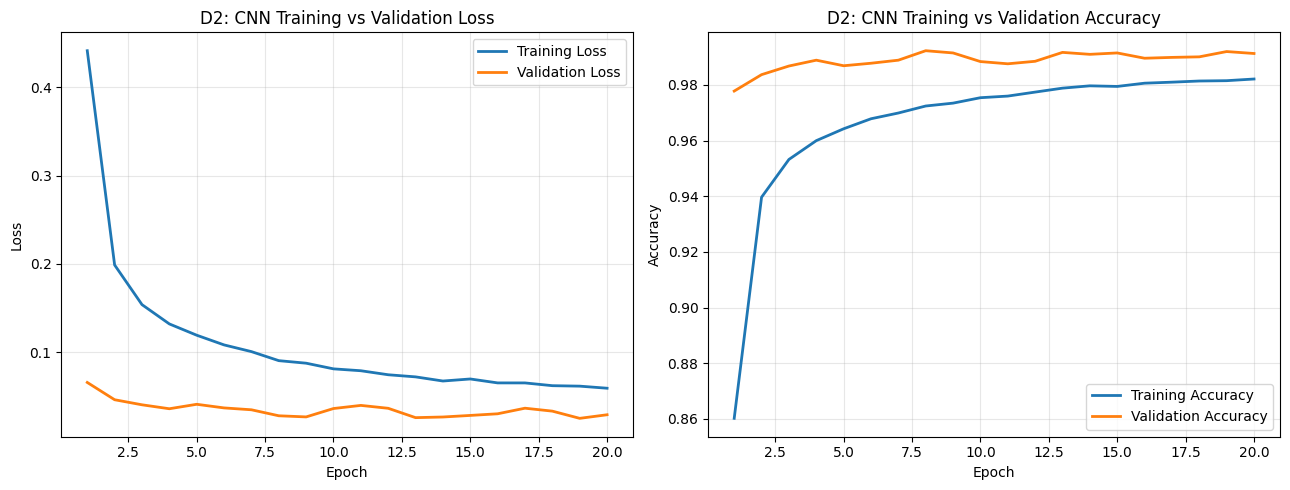

[D2] Training curves saved.


In [ ]:
# D2: Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

epochs = range(1, len(hist_cnn.history['loss']) + 1)

# Loss
axes[0].plot(epochs, hist_cnn.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(epochs, hist_cnn.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('D2: CNN Training vs Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs, hist_cnn.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(epochs, hist_cnn.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('D2: CNN Training vs Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('d2_cnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("[D2] Training curves saved.")

In [ ]:
# D2: Evaluate CNN on test set
y_pred_cnn_proba = cnn_model.predict(X_test_mnist, verbose=0)
y_pred_cnn = np.argmax(y_pred_cnn_proba, axis=1)

print("\n" + "="*60)
print("D2: CNN EVALUATION METRICS")
print("="*60)

acc_cnn = accuracy_score(y_test_mnist, y_pred_cnn)
f1_cnn_macro = f1_score(y_test_mnist, y_pred_cnn, average='macro')

print(f"\nTest Accuracy: {acc_cnn:.4f}")
print(f"Macro F1-Score: {f1_cnn_macro:.4f}")

print("\nConfusion Matrix:")
cm_cnn = confusion_matrix(y_test_mnist, y_pred_cnn)
print(cm_cnn.shape)


D2: CNN EVALUATION METRICS

Test Accuracy: 0.9913
Macro F1-Score: 0.9913

Confusion Matrix:
(10, 10)


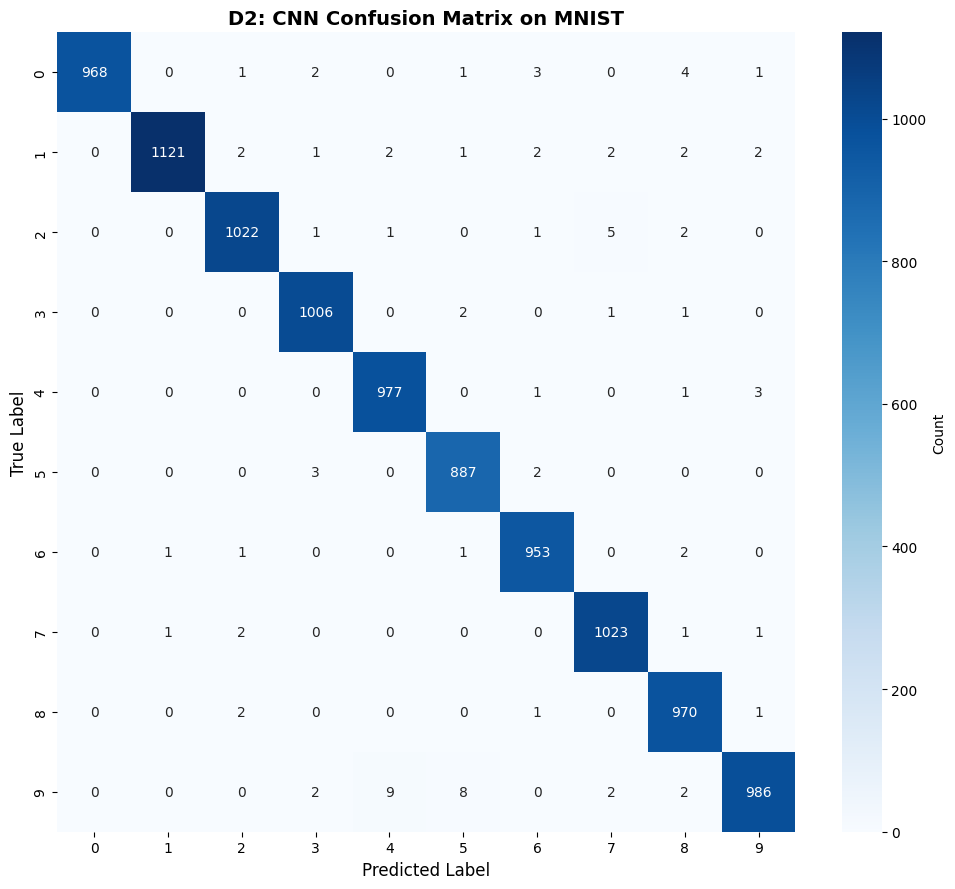

[D2] Confusion matrix heatmap saved.


In [ ]:
# D2: Confusion Matrix Heatmap
fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={'label': 'Count'})
ax.set_ylabel('True Label', fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_title('D2: CNN Confusion Matrix on MNIST', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('d2_cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("[D2] Confusion matrix heatmap saved.")

In [ ]:
# D2: Identify most confused digit pairs
print("\nMost Confused Digit Pairs:")
print("-" * 60)

# Get off-diagonal elements
confused_pairs = []
for i in range(10):
    for j in range(10):
        if i != j:
            confused_pairs.append((cm_cnn[i, j], i, j))

confused_pairs.sort(reverse=True)
top_2 = confused_pairs[:2]

for count, digit1, digit2 in top_2:
    print(f"\nDigit {digit1} confused with {digit2}: {count} misclassifications")

print("\nWhy are these digit pairs difficult to distinguish?")
print("""
Typically confused digits:
  - 3 vs 8: Both have curved shapes
  - 4 vs 9: Similar vertical and curved components
  - 6 vs 0: Both round shapes
  - 1 vs 7: Both have vertical components
  
These confusions are due to visual similarity in handwriting styles.
""")


Most Confused Digit Pairs:
------------------------------------------------------------

Digit 9 confused with 4: 9 misclassifications

Digit 9 confused with 5: 8 misclassifications

Why are these digit pairs difficult to distinguish?

Typically confused digits:
  - 3 vs 8: Both have curved shapes
  - 4 vs 9: Similar vertical and curved components
  - 6 vs 0: Both round shapes
  - 1 vs 7: Both have vertical components

These confusions are due to visual similarity in handwriting styles.



In [ ]:
# D2: Compare CNN vs MLP baseline
print("\n" + "="*60)
print("D2: CNN vs MLP BASELINE COMPARISON")
print("="*60)

print(f"\nMLP Baseline:")
print(f"  Test Accuracy: {acc_mlp_baseline:.4f}")
print(f"  Training Time: {time_mlp_baseline:.2f}s")
print(f"  Total Epochs: {len(hist_mlp_baseline.history['loss'])}")
print(f"\nCNN:")
print(f"  Test Accuracy: {acc_cnn:.4f}")
print(f"  Training Time: {time_cnn:.2f}s")
print(f"  Total Epochs: {len(hist_cnn.history['loss'])}")

# Find epoch where CNN surpasses MLP
mlp_final_acc = hist_mlp_baseline.history['accuracy'][-1]
mlp_baseline_val_acc = hist_mlp_baseline.history['val_accuracy'][-1]

epochs_to_surpass = None
for epoch, cnn_acc in enumerate(hist_cnn.history['val_accuracy']):
    if cnn_acc > mlp_baseline_val_acc:
        epochs_to_surpass = epoch + 1
        break

if epochs_to_surpass:
    print(f"\nCNN surpasses MLP baseline validation accuracy after {epochs_to_surpass} epochs")
else:
    print(f"\nCNN does not surpass MLP baseline in the trained epochs")

print(f"\nAccuracy Improvement: {(acc_cnn - acc_mlp_baseline):.4f} ({((acc_cnn - acc_mlp_baseline)/acc_mlp_baseline)*100:.2f}%)")


D2: CNN vs MLP BASELINE COMPARISON

MLP Baseline:
  Test Accuracy: 0.9815
  Training Time: 52.49s
  Total Epochs: 20

CNN:
  Test Accuracy: 0.9913
  Training Time: 252.05s
  Total Epochs: 20

CNN surpasses MLP baseline validation accuracy after 2 epochs

Accuracy Improvement: 0.0098 (1.00%)


---
## D3: Visualising What the CNN Learned

In [ ]:
print("\n" + "="*60)
print("D3: VISUALISING CNN LEARNED FILTERS AND FEATURE MAPS")
print("="*60)

# Extract first Conv2D layer weights
conv_layer_1 = cnn_model.layers[0]
weights_conv1, biases_conv1 = conv_layer_1.get_weights()

print(f"\nFirst Conv2D Layer Weights Shape: {weights_conv1.shape}")
print(f"  - Kernel size: 3x3")
print(f"  - Input channels: 1 (grayscale)")
print(f"  - Output filters: 16")
print(f"\nWeights range: [{weights_conv1.min():.4f}, {weights_conv1.max():.4f}]")


D3: VISUALISING CNN LEARNED FILTERS AND FEATURE MAPS

First Conv2D Layer Weights Shape: (3, 3, 1, 16)
  - Kernel size: 3x3
  - Input channels: 1 (grayscale)
  - Output filters: 16

Weights range: [-0.9361, 0.5730]


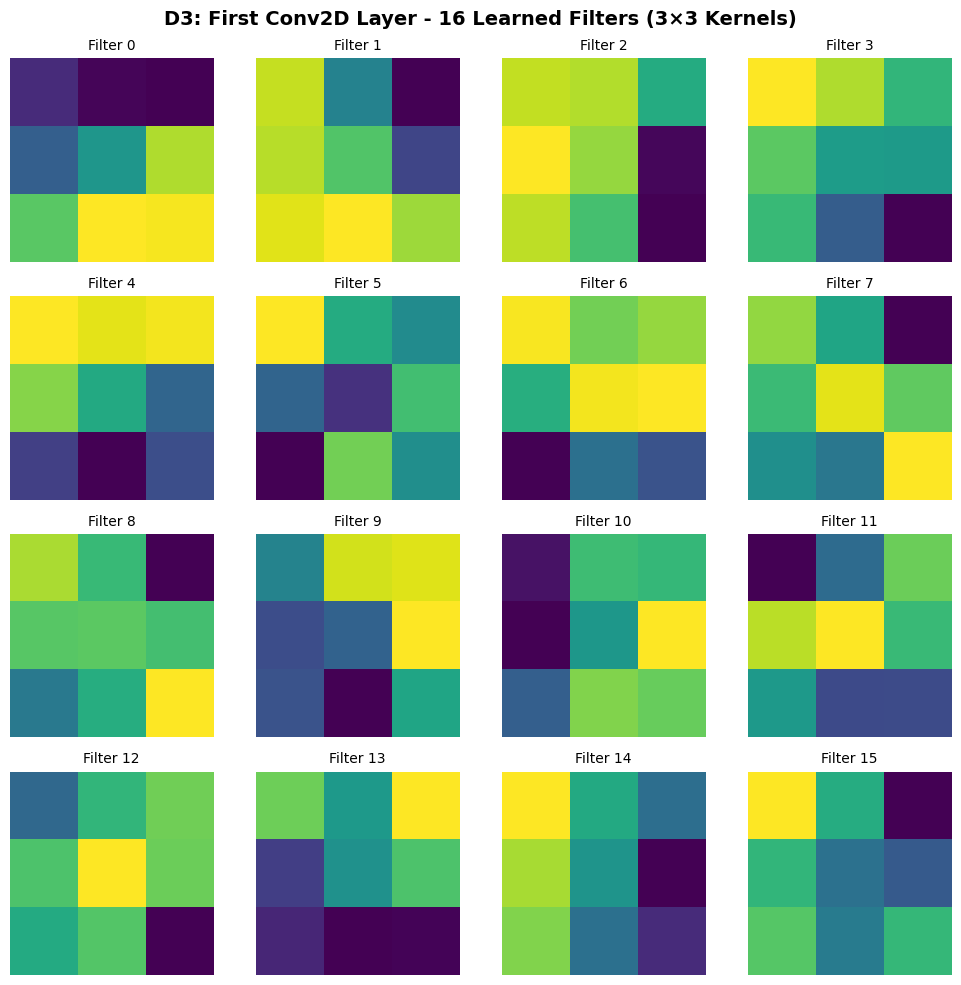

[D3] Filter visualization saved.


In [ ]:
# D3: Display 16 learned filters as 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('D3: First Conv2D Layer - 16 Learned Filters (3×3 Kernels)', 
             fontsize=14, fontweight='bold')

for i in range(16):
    ax = axes[i // 4, i % 4]
    
    # Extract and normalize filter
    filter_weights = weights_conv1[:, :, 0, i]
    filter_min = filter_weights.min()
    filter_max = filter_weights.max()
    filter_norm = (filter_weights - filter_min) / (filter_max - filter_min + 1e-8)
    
    ax.imshow(filter_norm, cmap='viridis')
    ax.set_title(f'Filter {i}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('d3_conv_filters.png', dpi=150, bbox_inches='tight')
plt.show()

print("[D3] Filter visualization saved.")


Extracting feature maps from first Conv2D layer...
Processing one test image per digit class (0-9)


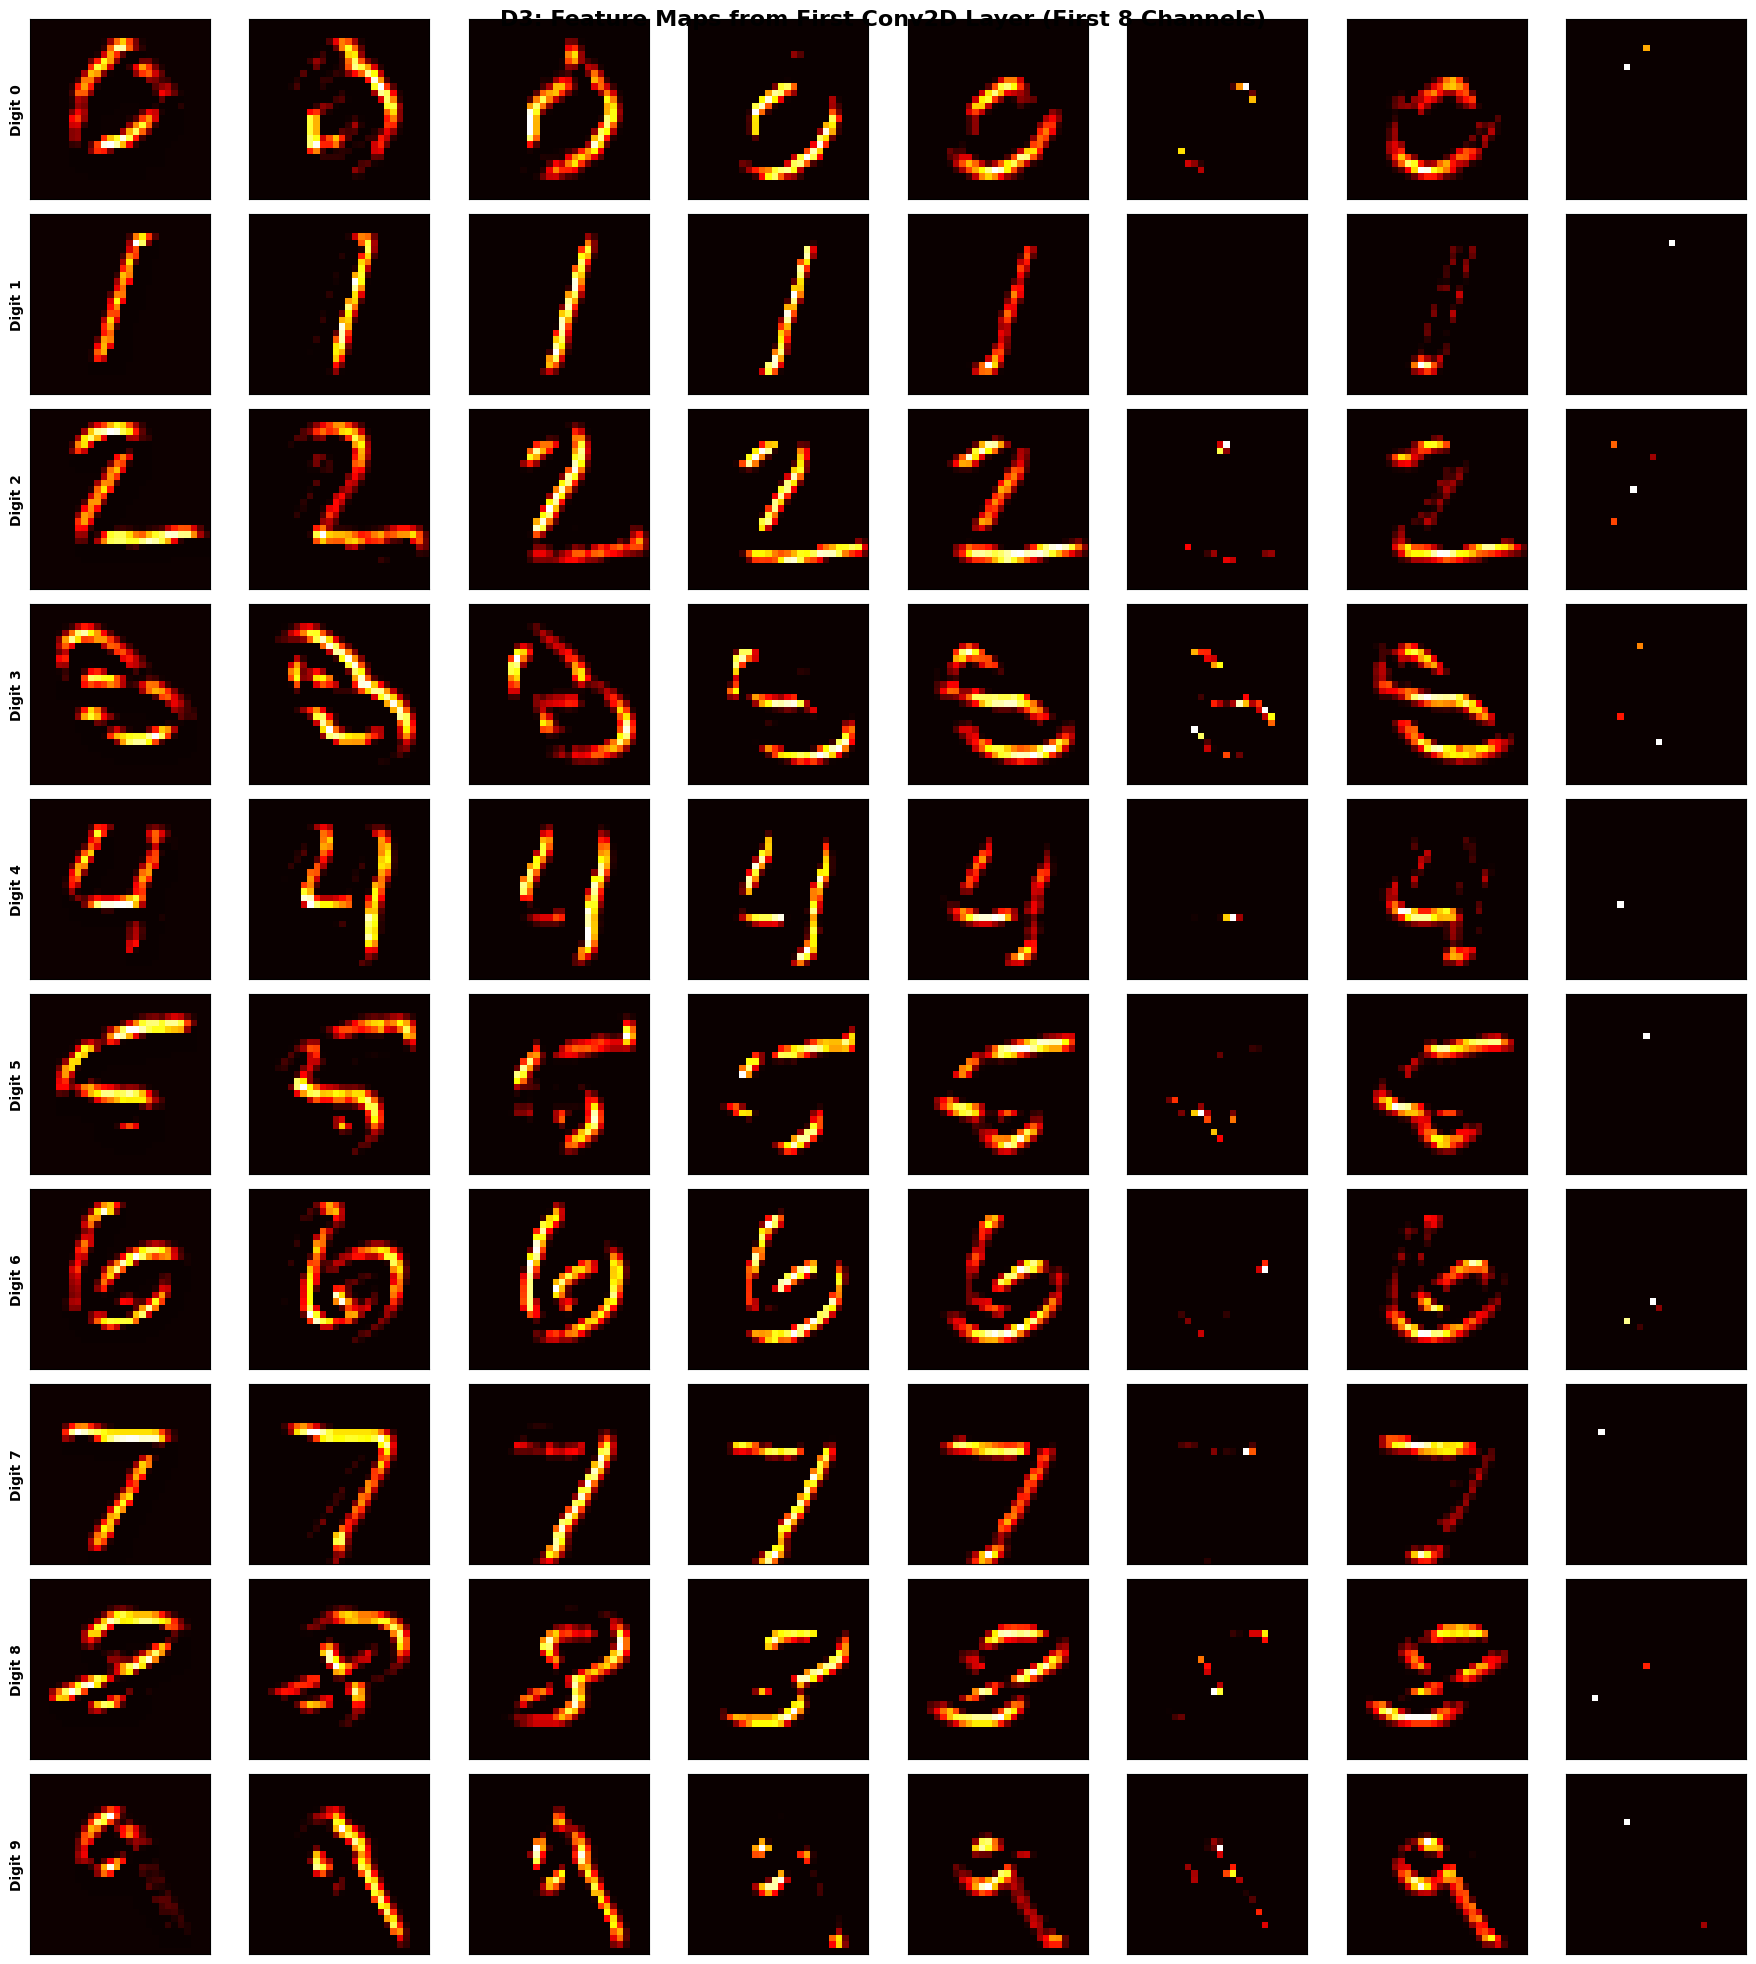

[D3] Feature map visualization saved.


In [ ]:
# D3: Extract feature maps for one image per digit class
from tensorflow.keras.models import Model

# Ensure model is built/called
_ = cnn_model(X_test_mnist[:1], training=False)

feature_map_model = Model(
    inputs=cnn_model.inputs,              # safer than cnn_model.input
    outputs=cnn_model.layers[0].output
)

print("\nExtracting feature maps from first Conv2D layer...")
print("Processing one test image per digit class (0-9)")

fig = plt.figure(figsize=(18, 20))
fig.suptitle('D3: Feature Maps from First Conv2D Layer (First 8 Channels)', 
             fontsize=16, fontweight='bold')

for digit_class in range(10):
    # Get one test image of this class
    idx = np.where(y_test_mnist == digit_class)[0][0]
    img = X_test_mnist[idx:idx+1]  # Keep batch dimension
    
    # Get feature maps
    feature_maps = feature_map_model.predict(img, verbose=0)[0]
    
    # Display first 8 channels in 2x4 grid
    for channel in range(8):
        ax = plt.subplot(10, 8, digit_class * 8 + channel + 1)
        
        fm = feature_maps[:, :, channel]
        fm_norm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
        
        ax.imshow(fm_norm, cmap='hot')
        
        if channel == 0:
            ax.set_ylabel(f'Digit {digit_class}', fontsize=10, fontweight='bold')
        else:
            ax.set_ylabel('')
        
        ax.set_xlabel('')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig('d3_feature_maps.png', dpi=150, bbox_inches='tight')
plt.show()

print("[D3] Feature map visualization saved.")

In [ ]:
# D3: Interpretation
print("\n" + "="*60)
print("D3: INTERPRETATION OF LEARNED FEATURES")
print("="*60)

print("""
What Visual Patterns Do Filters Detect?

The 16 learned filters in the first Conv2D layer respond to:
1. **Edge Detectors**: Filters that activate at vertical, horizontal, and diagonal edges
2. **Texture Detectors**: Filters sensitive to specific textures or patterns
3. **Curvature Detectors**: Filters that respond to curves and corners
4. **Blob Detectors**: Filters sensitive to dark/light blobs

Why Different Digits Produce Different Feature Maps:
Each digit (0-9) has unique visual characteristics:
  - Digit '1': Strong vertical edge activations
  - Digit '0': Strong circular/curved edge activations
  - Digit '8': Multiple loop/curve detections
  - Digit '5': Mixed horizontal and curved features

How This Builds Trust in the Model:
1. **Interpretability**: We can visualize what the CNN learns, unlike black-box models
2. **Feature Validity**: The learned filters match known patterns (edges, textures)
3. **Hierarchical Learning**: Early layers learn simple features (edges), 
   which are combined in deeper layers to recognize complex patterns
4. **Robustness**: The CNN learns invariant features that generalize across different
   handwriting styles

CNNs vs Fully Connected Networks:
1. **Parameter Sharing**: Conv filters share weights across the image
   → Fewer parameters, more efficient training
2. **Local Connectivity**: Each neuron only connects to nearby pixels
   → Better captures spatial structure
3. **Translation Invariance**: Filters detect patterns regardless of position
   → More robust to shifted/rotated digits
4. **Interpretable Features**: We can visualize what each filter learns
   → Fully connected networks' hidden units are harder to interpret
""")


D3: INTERPRETATION OF LEARNED FEATURES

What Visual Patterns Do Filters Detect?

The 16 learned filters in the first Conv2D layer respond to:
1. **Edge Detectors**: Filters that activate at vertical, horizontal, and diagonal edges
2. **Texture Detectors**: Filters sensitive to specific textures or patterns
3. **Curvature Detectors**: Filters that respond to curves and corners
4. **Blob Detectors**: Filters sensitive to dark/light blobs

Why Different Digits Produce Different Feature Maps:
Each digit (0-9) has unique visual characteristics:
  - Digit '1': Strong vertical edge activations
  - Digit '0': Strong circular/curved edge activations
  - Digit '8': Multiple loop/curve detections
  - Digit '5': Mixed horizontal and curved features

How This Builds Trust in the Model:
1. **Interpretability**: We can visualize what the CNN learns, unlike black-box models
2. **Feature Validity**: The learned filters match known patterns (edges, textures)
3. **Hierarchical Learning**: Early layers l

---
## Summary

In [ ]:
# Final summary of all results
print("\n" + "="*80)
print("COMPLETE SUMMARY: PARTS C & D")
print("="*80)

print("\nPART C: Artificial Neural Networks on Heart Disease Data")
print("-" * 80)
print(f"\nC1: Single-Layer Perceptron")
print(f"  Test Accuracy: {acc_slp:.4f}, F1: {f1_slp:.4f}, AUC: {auc_slp:.4f}")
print(f"  Interpretation: Linear model, fundamentally limited for non-linear problem")

print(f"\nC2: Multi-Layer Perceptron")
print(f"  Best Architecture: {best_arch_config['description']}")
print(f"  Test Accuracy: {acc_mlp:.4f}, F1: {f1_mlp:.4f}, AUC: {auc_mlp:.4f}")
print(f"  5-Fold CV: {cv_acc_mean:.4f} ± {cv_acc_std:.4f} (accuracy)")
print(f"  Early Stopping: Triggered at epoch {es_epoch}")

print(f"\nC3: Ablation Study")
print(f"  Most Important Component: {most_important}")
print(f"  Performance Impact: F1 drop of {max_drop:.4f}")

print("\n" + "-" * 80)
print("PART D: CNN on MNIST Digit Recognition")
print("-" * 80)
print(f"\nD1: Data Preparation & Baseline")
print(f"  MLP Baseline Test Accuracy: {acc_mlp_baseline:.4f}")

print(f"\nD2: Lightweight CNN")
print(f"  CNN Test Accuracy: {acc_cnn:.4f}")
print(f"  Macro F1-Score: {f1_cnn_macro:.4f}")
print(f"  Improvement over MLP: {(acc_cnn - acc_mlp_baseline):.4f}")
if epochs_to_surpass:
    print(f"  Epochs to surpass MLP: {epochs_to_surpass}")

print(f"\nD3: Visualisation")
print(f"  Filters learned meaningful edge and texture detectors")
print(f"  Feature maps are interpretable and build model trust")

print("\n" + "="*80)
print("All cells completed successfully!")
print("="*80)


COMPLETE SUMMARY: PARTS C & D

PART C: Artificial Neural Networks on Heart Disease Data
--------------------------------------------------------------------------------

C1: Single-Layer Perceptron
  Test Accuracy: 0.8667, F1: 0.8571, AUC: 0.9464
  Interpretation: Linear model, fundamentally limited for non-linear problem

C2: Multi-Layer Perceptron
  Best Architecture: Deep: 4 hidden layers (256, 128, 64, 32)
  Test Accuracy: 0.8167, F1: 0.7925, AUC: 0.9252
  5-Fold CV: 0.8124 ± 0.0409 (accuracy)
  Early Stopping: Triggered at epoch 47

C3: Ablation Study
  Most Important Component: Variant B (Sigmoid)
  Performance Impact: F1 drop of 0.8077

--------------------------------------------------------------------------------
PART D: CNN on MNIST Digit Recognition
--------------------------------------------------------------------------------

D1: Data Preparation & Baseline
  MLP Baseline Test Accuracy: 0.9815

D2: Lightweight CNN
  CNN Test Accuracy: 0.9913
  Macro F1-Score: 0.9913
  

## Part E: Local Front-End Dashboard

This section prepares artifacts and runs a local Streamlit dashboard for heart disease prediction on localhost.

Run the next cells in order.



In [ ]:
# E0: Export artifacts for local dashboard
import os
import json
import joblib
import numpy as np
import pandas as pd

os.makedirs('artifacts', exist_ok=True)

# Save trained MLP model from Part C2
mlp_final.save('artifacts/heart_mlp.keras')

# Save scaler from preprocessing
joblib.dump(scaler, 'artifacts/heart_scaler.joblib')

# Compute simple global input importance from first Dense layer
# (mean absolute input weights across hidden units)
first_dense_idx = None
for i, lyr in enumerate(mlp_final.layers):
    if 'Dense' in lyr.__class__.__name__:
        first_dense_idx = i
        break

W = mlp_final.layers[first_dense_idx].get_weights()[0]  # shape: [n_features, hidden_units]
importance = np.mean(np.abs(W), axis=1)

feature_cols = X_train_sm.columns.tolist()
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': importance})
imp_df = imp_df.sort_values('importance', ascending=False)
imp_df.to_csv('artifacts/input_importance.csv', index=False)

# Build one real test patient in original (unscaled) feature space for form defaults
default_idx = 0
default_encoded = X_test.iloc[default_idx:default_idx+1].copy()
default_raw = default_encoded.copy()
default_raw[CONT_COLS] = scaler.inverse_transform(default_encoded[CONT_COLS])

def recover_categorical_value(row, prefix):
    cols = [c for c in feature_cols if c.startswith(prefix + '_')]
    vals = [c.split('_', 1)[1] for c in cols]
    if len(cols) == 0:
        return None
    arr = row[cols].values.astype(float)
    if arr.max() <= 0:
        return float(vals[0])
    return float(vals[int(np.argmax(arr))])

# Raw 13-feature defaults
default_patient = {
    'age': float(default_raw['age'].iloc[0]),
    'sex': int(round(float(default_raw['sex'].iloc[0]))),
    'cp': int(round(recover_categorical_value(default_raw.iloc[0], 'cp'))),
    'trestbps': float(default_raw['trestbps'].iloc[0]),
    'chol': float(default_raw['chol'].iloc[0]),
    'fbs': int(round(float(default_raw['fbs'].iloc[0]))),
    'restecg': int(round(recover_categorical_value(default_raw.iloc[0], 'restecg'))),
    'thalach': float(default_raw['thalach'].iloc[0]),
    'exang': int(round(float(default_raw['exang'].iloc[0]))),
    'oldpeak': float(default_raw['oldpeak'].iloc[0]),
    'slope': int(round(recover_categorical_value(default_raw.iloc[0], 'slope'))),
    'ca': int(round(float(default_raw['ca'].iloc[0]))),
    'thal': int(round(recover_categorical_value(default_raw.iloc[0], 'thal'))),
}

meta = {
    'model_columns': feature_cols,
    'continuous_cols': CONT_COLS,
    'categorical_cols': ['cp', 'restecg', 'slope', 'thal'],
    'default_patient': default_patient
}

with open('artifacts/heart_meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f, indent=2)

print('[E0] Artifacts exported to ./artifacts')
print(' - heart_mlp.keras')
print(' - heart_scaler.joblib')
print(' - input_importance.csv')
print(' - heart_meta.json')
print('Default test patient target:', int(y_test[default_idx]))



In [ ]:
# E3: Localhost run command (single command for grader)
print('Run this command from assignment folder:')
print('streamlit run app.py')



In [ ]:
# Optional: quick validation of E artifacts
import os
for f in [
    'artifacts/heart_mlp.keras',
    'artifacts/heart_scaler.joblib',
    'artifacts/input_importance.csv',
    'artifacts/heart_meta.json',
    'app.py'
]:
    print(f, '->', 'OK' if os.path.exists(f) else 'MISSING')

